# Dirk Messing around with some motion detection

In [34]:
# Tunable Parameters 
background_threshold = 0.25

filter_window_size = 20

In [35]:
# Get a list of files

import glob

projectDir = './images/stability_FP2/cropped/*.tiff'
imagefiles = glob.glob(projectDir)
len(imagefiles)

50

In [36]:
# Function snip-it to enable very simple animation in Jupyter Cells

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

def show_animation(delay=0.01):
    fig = plt.gcf();
    time.sleep(delay);       # Sleep for half a second to slow down the animation
    clear_output(wait=True); # Clear output for dynamic display
    display(fig);            # Reset display
    fig.clear();             # Prevent overlapping and layered plots

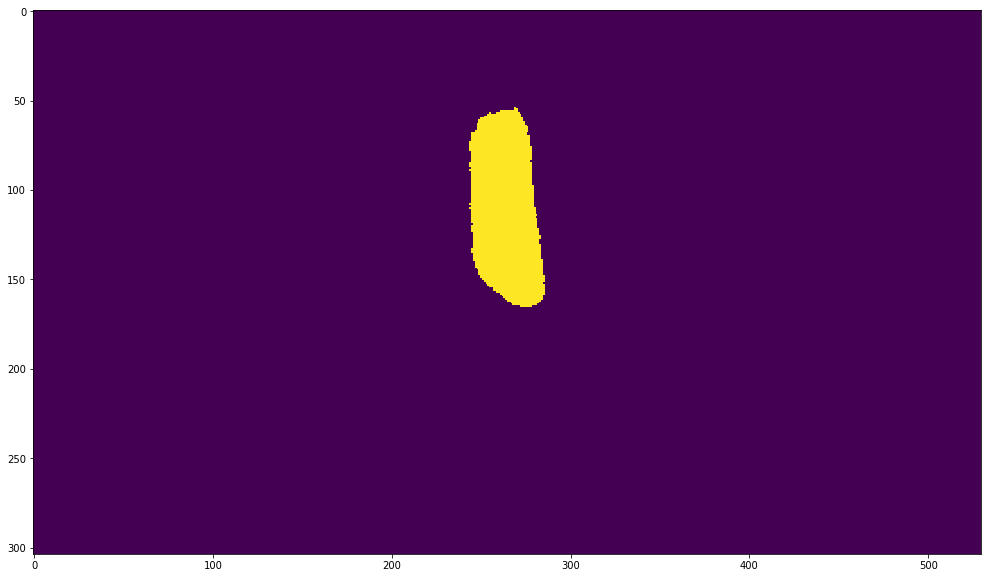

In [37]:
#Read in first file from the list and normailze to [0,1] 
# Threshold for signals greater than 0.3

import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import imageio

prev = imageio.imread(imagefiles[0])/255.0 
prev = ndimage.median_filter(prev, filter_window_size) > background_threshold
plt.figure(figsize=(20,10))
plt.imshow(prev)

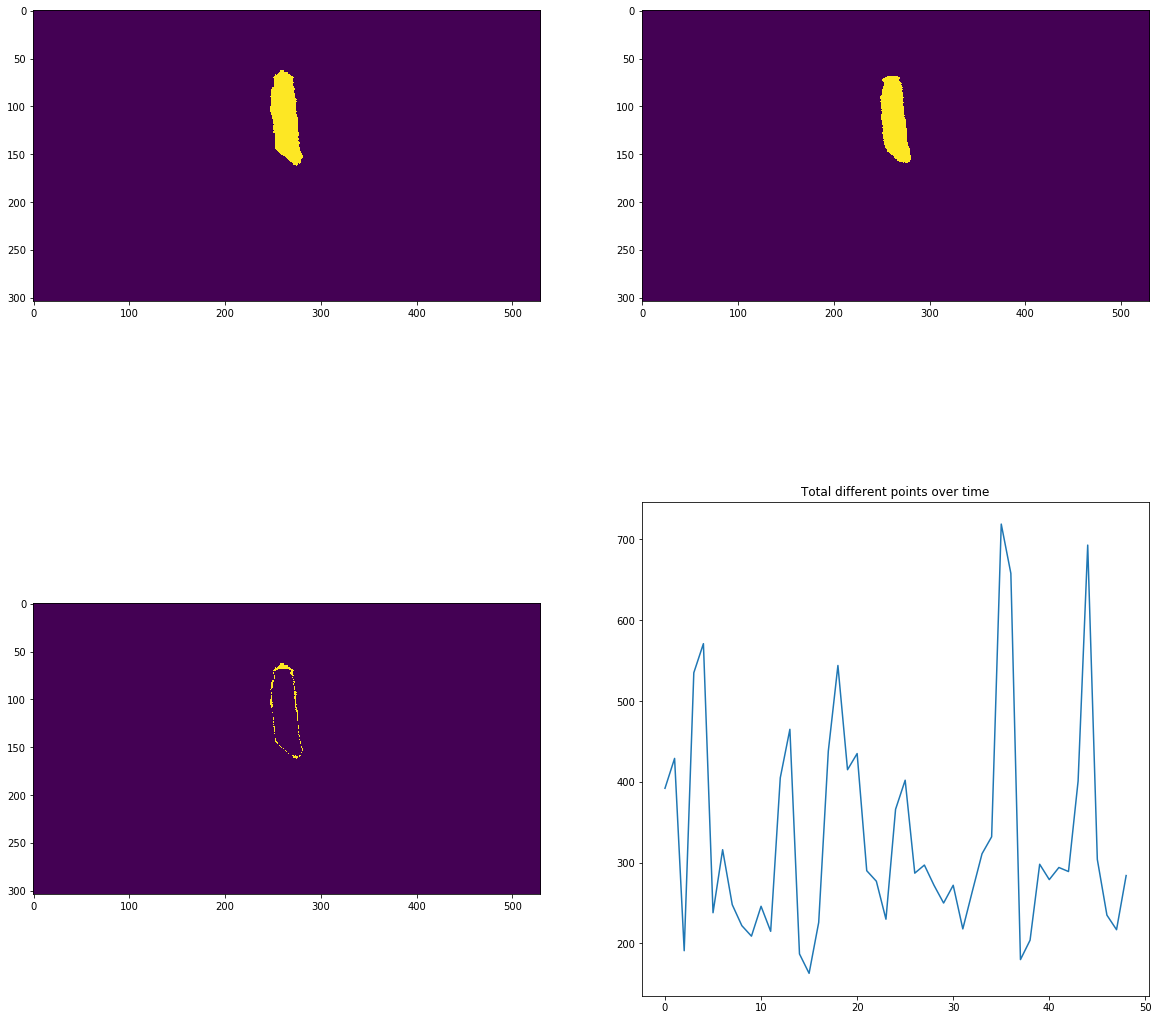

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

...

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

In [5]:
# Loop over images and subtrac previous to see results

tot = []
for file in imagefiles[1:]:
    
    im = imageio.imread(file)/255.0 
    im = ndimage.median_filter(im, 8) > 0.3
    
    print(f"min={np.min(im)}, max={np.max(im)}")
    
    #diff = np.abs(im-prev);
    diff = (im != prev)
    print(diff.shape);
    tot.append(np.sum(diff));
    
    fig = plt.figure(figsize=(20,20));
    ax = fig.add_subplot(2,2,1);
    pdiff = ax.imshow(prev);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,2);
    pdiff = ax.imshow(im);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,3);
    pdiff = ax.imshow(diff);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,4);
    ax.set_title("Total different points over time")
    ax.plot(tot);
    
    show_animation();
    prev = im

# Version 2 

In [6]:
background_threshold = 0.3
filter_window_size = 20

In [7]:
# Function snip-it to enable very simple animation in Jupyter Cells

def show_animation(delay=0.01):
    fig = plt.gcf();
    time.sleep(delay);       # Sleep for half a second to slow down the animation
    clear_output(wait=True); # Clear output for dynamic display
    display(fig);            # Reset display
    fig.clear();             # Prevent overlapping and layered plots

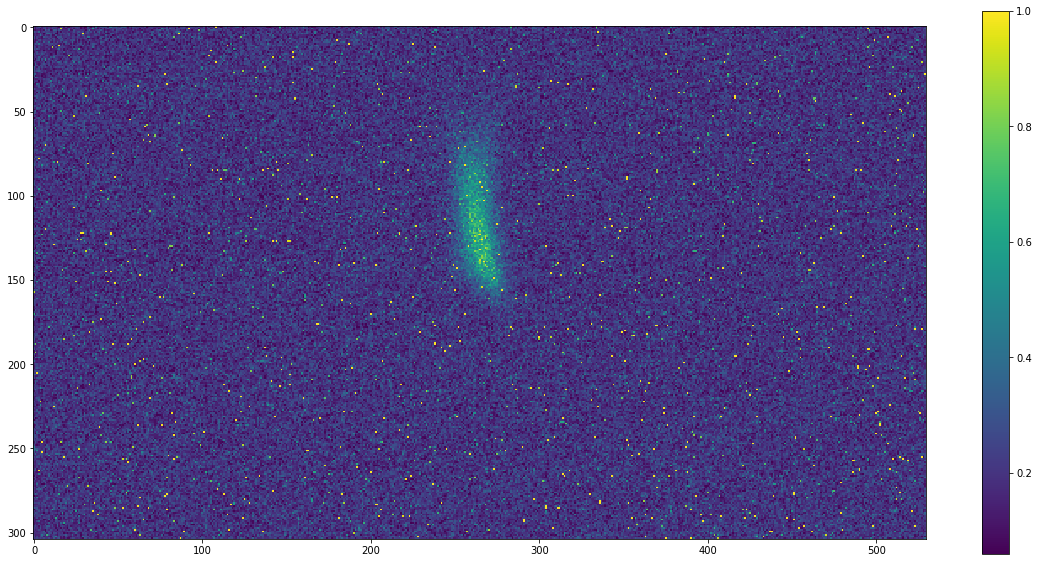

In [8]:
#Read in first file from the list and normailze to [0,1] 
# Threshold for signals greater than 0.3

prev = imageio.imread(imagefiles[0])/255.0 


projectDir = './stability_hendrik_sara/*.tiff'
imagefiles = glob.glob(projectDir)
len(imagefiles)

# Function snip-it to enable very simple animation in Jupyter Cells

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

def show_animation(delay=0.01):
    fig = plt.gcf();
    time.sleep(delay);       # Sleep for half a second to slow down the animation
    clear_output(wait=True); # Clear output for dynamic display
    display(fig);            # Reset display
    fig.clear();             # Prevent overlapping and layered plots
plt.figure(figsize=(20,10))
plt.imshow(prev)
plt.colorbar()

Text(0.5, 1.0, 'Historgams for Grayscale Image')

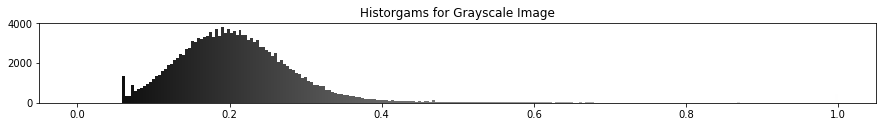

In [9]:
#Histogram snip-it for a grayscale image
import skimage.filters as filters

fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(311)  
i = 0
N, bins, patches = ax1.hist(prev.ravel(), bins=255, range=(0, 1), color='gray');
for thispatch in patches:
    #color = plt.cm.viridis(i/len(patches))
    frac = i/len(patches)
    thispatch.set_facecolor((frac,frac,frac))
    i += 1
    
plt.title('Historgams for Grayscale Image')

In [10]:
#apply median filter

prev = ndimage.median_filter(prev, filter_window_size) # Get a list of files


In [11]:
# Loop over images and subtrac previous to see results

tot = []
for file in imagefiles[1:]:
    
    im = imageio.imread(file)/255
    im = ndimage.median_filter(im, filter_window_size)
    
    print(f"min={np.min(im)}, max={np.max(im)}")
    
    diff = np.abs(im-prev);
    #diff = (im != prev)
    print(diff.shape);
    tot.append(np.sum(diff));
    
    fig = plt.figure(figsize=(20,20));
    ax = fig.add_subplot(2,2,1);
    pdiff = ax.imshow(prev);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,2);
    pdiff = ax.imshow(im);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,3);
    pdiff = ax.imshow(diff);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,4);
    ax.set_title("Total different points over time")
    ax.plot(tot);
    
    show_animation();
    prev = im

# Version 3

In [12]:
# Function snip-it to enable very simple animation in Jupyter Cells

def show_animation(delay=0.01):
    fig = plt.gcf();
    time.sleep(delay);       # Sleep for half a second to slow down the animation
    clear_output(wait=True); # Clear output for dynamic display
    display(fig);            # Reset display
    fig.clear();             # Prevent overlapping and layered plots

In [13]:
#Read in first file from the list and normailze to [0,1] 
# Threshold for signals greater than 0.3

prev = imageio.imread(imagefiles[0])/255.0 #normalizing
prev = ndimage.median_filter(prev, filter_window_size) # Get a list of files

prev[prev < background_threshold] = 0

len(imagefiles)

# Function snip-it to enable very simple animation in Jupyter Cells


def show_animation(delay=0.01):
    fig = plt.gcf();
    time.sleep(delay);       # Sleep for half a second to slow down the animation
    clear_output(wait=True); # Clear output for dynamic display
    display(fig);            # Reset display
    fig.clear();             # Prevent overlapping and layered plots
plt.figure(figsize=(20,10))
plt.imshow(prev)

IndexError: list index out of range

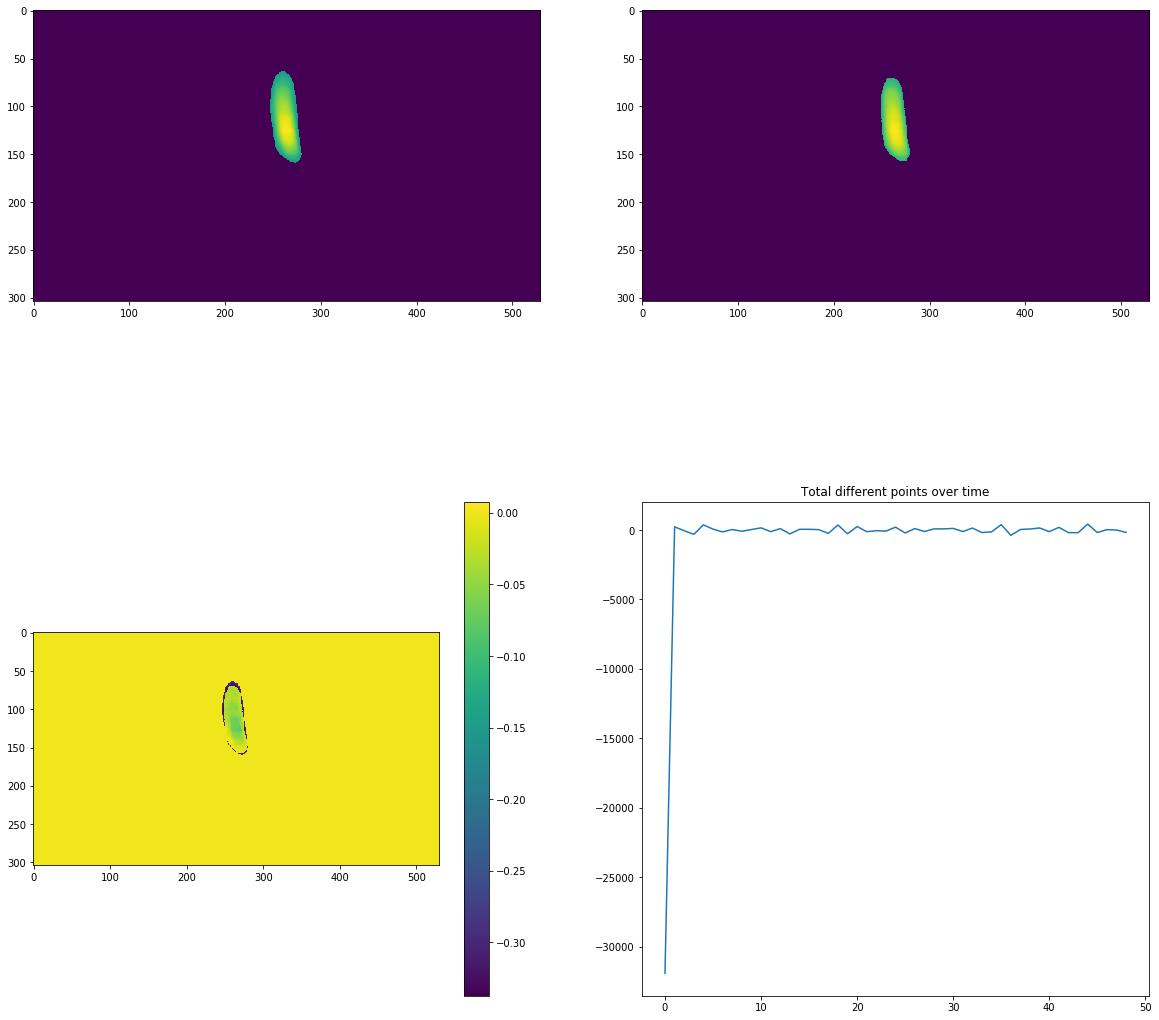

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

...

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

In [17]:
# Loop over images and subtrac previous to see results

tot = []
for file in imagefiles[1:]:
    
    im = imageio.imread(file)/255
    im = ndimage.median_filter(im, filter_window_size)
    im[im < background_threshold] = 0
    
    print(f"min={np.min(im)}, max={np.max(im)}")
    
    diff = np.abs(im-prev);
    #diff = (im != prev)
    print(diff.shape);
    tot.append(np.sum(diff));
    
    fig = plt.figure(figsize=(20,20));
    ax = fig.add_subplot(2,2,1);
    pdiff = ax.imshow(prev);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,2);
    pdiff = ax.imshow(im);
    #fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,3);
    pdiff = ax.imshow(diff);
    fig.colorbar(pdiff, ax=ax);
    
    ax = fig.add_subplot(2,2,4);
    ax.set_title("Total different points over time")
    ax.plot(tot);
    
    show_animation();
    prev = im